#### Scenario: "The Board Pack"
##### The owner found your analysis useful and is now taking it to her two investors. She has asked for a short pack: three charts, each answering one question, each able to stand on its own.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("../data/daily_sales.csv", parse_dates=["date"])
outlets = pd.read_csv("../data/outlets.csv")
tickets = pd.read_csv("../data/tickets_week.csv", parse_dates=["txn_datetime"])
decision = pd.read_csv("../data/lesson19_decision.csv", index_col="outlet_id")

names = outlets.set_index("outlet_id")["outlet_name"].to_dict()
sns.set_theme(style="whitegrid", palette="colorblind")

#### Challenge 1: The critique and redesign
##### Below is a chart request as it usually arrives, and a first attempt at it.

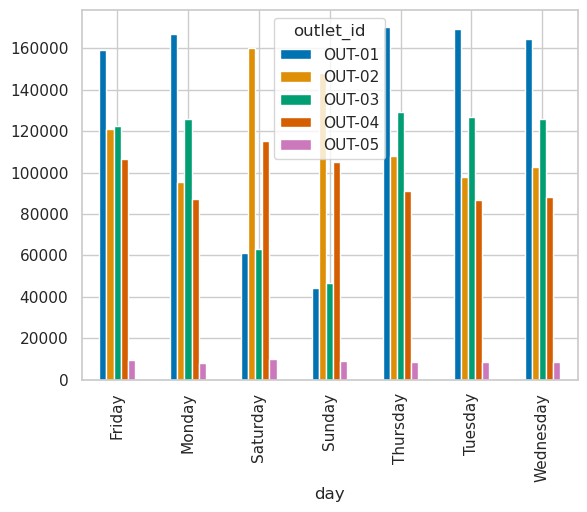

In [30]:
# The "before" -- please run this, and do not fix it yet.
weekday = sales.copy()
weekday["day"] = weekday["date"].dt.day_name()
weekday.pivot_table(index="day", columns="outlet_id", values="revenue_sgd", aggfunc="sum").plot(kind="bar")
plt.show()

#### Check the dataset

In [31]:
weekday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         6840 non-null   datetime64[ns]
 1   outlet_id    6840 non-null   object        
 2   daypart      6840 non-null   object        
 3   tickets      6840 non-null   int64         
 4   items        6840 non-null   int64         
 5   revenue_sgd  6840 non-null   float64       
 6   day          6840 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 374.2+ KB


#### Redesign the chart

##### Re-arrange x axis in alphabetical order, sum up by average per day, change colours, re-label outlet name, insert title/units/message

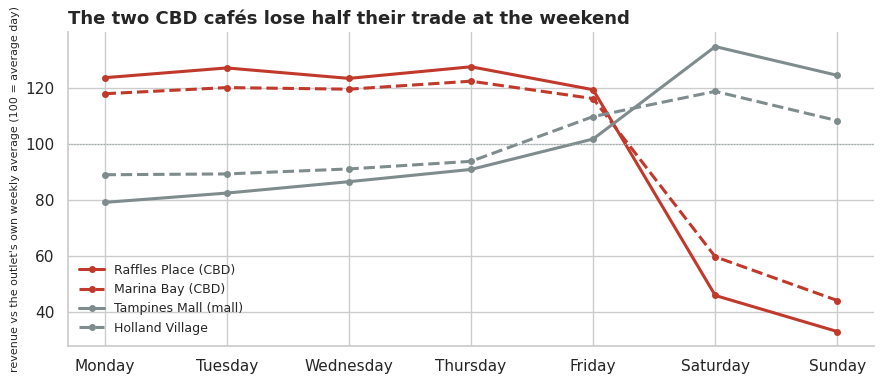

In [44]:
# One row per outlet per day, so we can average by weekday honestly.
daily = sales.groupby(["date", "outlet_id"], as_index=False)["revenue_sgd"].sum()
daily["day"] = daily["date"].dt.day_name()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
keep = ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]

avg = (
    daily[daily["outlet_id"].isin(keep)]
    .pivot_table(index="day", columns="outlet_id", values="revenue_sgd", aggfunc="mean")
    .reindex(order)
)

# Index each outlet to its own weekday average = 100, so shapes are comparable across sizes.
indexed = avg.div(avg.mean(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(9, 4))

# The message is a TWO-GROUP comparison, so it needs two colours -- one per group, not one
# per outlet. Same line style within a group; the reader learns "red = CBD" once and is done.
styles = {
    "OUT-01": ("#c0392b", "-", "Raffles Place (CBD)"),
    "OUT-03": ("#c0392b", "--", "Marina Bay (CBD)"),
    "OUT-02": ("#7f8c8d", "-", "Tampines Mall (mall)"),
    "OUT-04": ("#7f8c8d", "--", "Holland Village"),
}
for outlet, (colour, dash, label) in styles.items():
    ax.plot(indexed.index, indexed[outlet], color=colour, linestyle=dash, linewidth=2.2,
            marker="o", markersize=4, label=label)

ax.axhline(100, color="#95a5a6", linewidth=0.8, linestyle=":")
ax.set_title("The two CBD cafés lose half their trade at the weekend",
             loc="left", fontsize=13, weight="bold")
ax.set_ylabel("revenue vs the outlet's own weekly average (100 = average day)", fontsize=8)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#### Challenge 2: The distribution chart
##### The investors ask: "is Marina Bay's problem that customers spend less, or that there are fewer of them?"

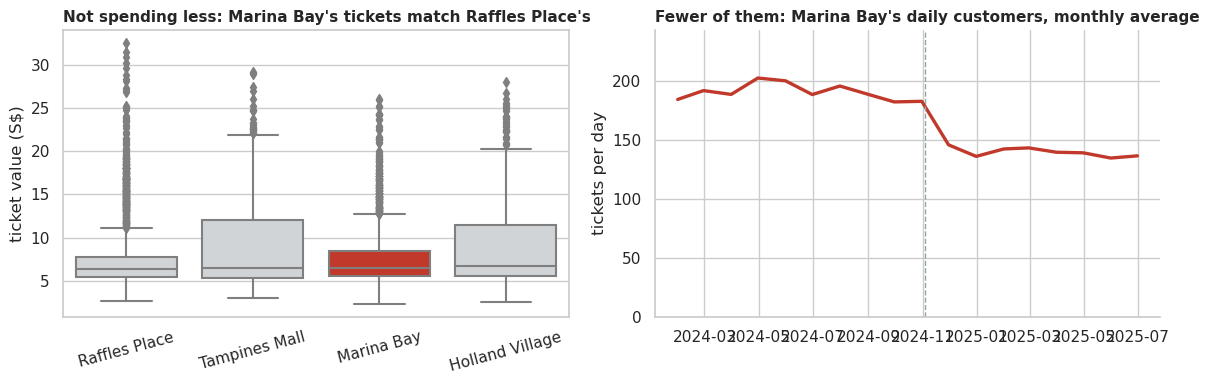

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- left: do they spend less per visit? (no) --------------------------------
keep = ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]

sns.boxplot(data=tickets[tickets["outlet_id"].isin(keep)], x="outlet_id", y="amount_sgd",
            order=keep, color="#cfd4d8", ax=axes[0])

# Recolour just the Marina Bay box. Doing it this way (rather than with `palette=`) works on
# every seaborn version -- the boxes are ordinary matplotlib patches, in the order you asked for.
axes[0].patches[keep.index("OUT-03")].set_facecolor("#c0392b")
axes[0].set_xticklabels([names[o] for o in keep], rotation=15)
axes[0].set_title("Not spending less: Marina Bay's tickets match Raffles Place's",
                  loc="left", fontsize=11, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("ticket value (S$)")

# ---- right: are there fewer of them? (yes) -----------------------------------
counts = (
    sales[sales["outlet_id"] == "OUT-03"]
    .groupby("date")["tickets"].sum()
    .resample("M").mean()
)

axes[1].plot(counts.index, counts.values, color="#c0392b", linewidth=2.4)
axes[1].axvline(pd.Timestamp("2024-11-04"), color="#95a5a6", linestyle="--", linewidth=1)
axes[1].set_ylim(0, counts.max() * 1.2)
axes[1].set_title("Fewer of them: Marina Bay's daily customers, monthly average",
                  loc="left", fontsize=11, weight="bold")
axes[1].set_ylabel("tickets per day")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

#### Challenge 3: Your own one slide
##### Build a single figure for the investors. The message is yours to choose, but it must be defensible from the data, and the figure must work with no voiceover.

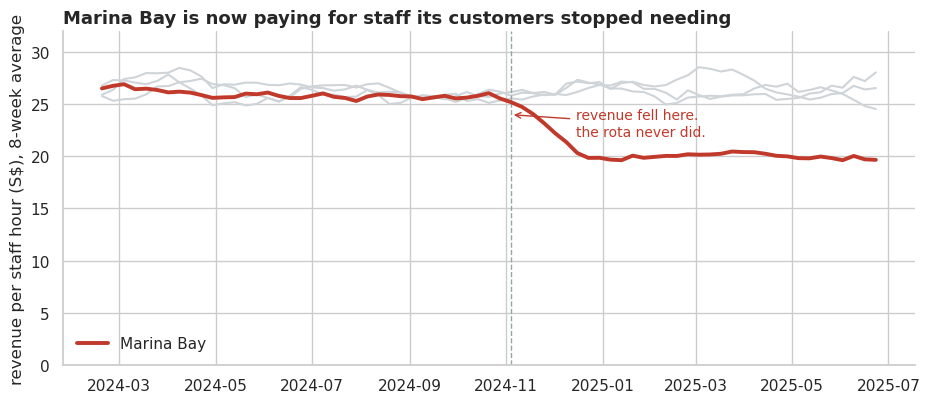

In [53]:
weekly = (
    sales.groupby(["outlet_id", pd.Grouper(key="date", freq="W-MON", label="left")])["revenue_sgd"]
    .sum().reset_index().rename(columns={"date": "week_start"})
)
roster = pd.read_csv("../data/roster.csv", parse_dates=["week_start"])
staffed = weekly.merge(roster, on=["outlet_id", "week_start"], how="inner")
staffed["per_hour"] = staffed["revenue_sgd"] / staffed["staff_hours"]

fig, ax = plt.subplots(figsize=(9.5, 4.2))

for outlet in ["OUT-01", "OUT-02", "OUT-04", "OUT-03"]:
    d = staffed[staffed["outlet_id"] == outlet].sort_values("week_start")
    smooth = d.set_index("week_start")["per_hour"].rolling(8).mean()
    accent = outlet == "OUT-03"
    ax.plot(smooth.index, smooth.values,
            color="#c0392b" if accent else "#cfd4d8",
            linewidth=2.8 if accent else 1.5,
            zorder=3 if accent else 1,
            label=names[outlet] if accent else None)

ax.axvline(pd.Timestamp("2024-11-04"), color="#95a5a6", linestyle="--", linewidth=1)
ax.annotate("revenue fell here.\nthe rota never did.",
            xy=(pd.Timestamp("2024-11-04"), 24),
            xytext=(pd.Timestamp("2024-12-15"), 22),
            fontsize=10, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", linewidth=1))

ax.set_ylim(0, 32)
ax.set_ylabel("revenue per staff hour (S$), 8-week average")
ax.set_title("Marina Bay is now paying for staff its customers stopped needing",
             loc="left", fontsize=13, weight="bold")
ax.legend(frameon=False, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig("../visualisations/my_board_slide.png", dpi=150, bbox_inches="tight")
plt.show()